# CSI Phase And Trajectory Plots

This notebook reads the NetCDF xarray dataset produced by `processing/extract_csi_from_smb.py` from `data/csi.nc` or the newest timestamped `data/csi_*.nc`, plots CSI phase in degrees for all hostnames versus cycle ID, and plots the rover trajectory in 2D.


In [26]:
# Install pip packages in the current Jupyter kernel when needed.
import sys

!{sys.executable} -m pip install numpy matplotlib xarray requests pyyaml scipy pillow



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation, PillowWriter
from matplotlib.colors import Normalize
import numpy as np
import requests
import xarray as xr
import yaml

POSITIONS_URL = (
    'https://raw.githubusercontent.com/techtile-by-dramco/'
    'techtile-description/refs/heads/main/geometry/'
    'techtile_antenna_locations.yml'
)

plt.style.use('seaborn-v0_8-whitegrid')

candidate_paths = sorted(
    Path('../data').glob('csi*.nc'),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)
candidate_paths += [
    Path('csi.nc'),
    Path('processing/csi_positions.nc'),
]

for candidate in candidate_paths:
    if candidate.exists():
        DATASET_PATH = candidate.resolve()
        break
else:
    raise FileNotFoundError(
        'Could not find csi.nc. Run processing/extract_csi_from_smb.py first, or update candidate_paths.'
    )

ds = xr.open_dataset(DATASET_PATH)
print(f'Loaded dataset: {DATASET_PATH}')
print(ds)


def load_antenna_positions(positions_url=POSITIONS_URL):
    response = requests.get(positions_url, timeout=20)
    response.raise_for_status()
    config = yaml.safe_load(response.text)
    positions = {}
    for entry in config['antennes']:
        tile = str(entry['tile']).upper()
        # Mirror compute-tx-weights-sionna.py and use channels[1].
        channel = entry['channels'][1]
        positions[tile] = np.array([channel['x'], channel['y'], channel['z']], dtype=float)
    return positions


try:
    antenna_positions = load_antenna_positions()
    print(f'Loaded antenna positions from: {POSITIONS_URL}')
    print(f'Mapped {len(antenna_positions)} tile positions')
    missing_positions = sorted(
        hostname
        for hostname in ds['hostname'].values.astype(str)
        if hostname.upper() not in antenna_positions
    )
    if missing_positions:
        print('Hostnames without antenna position mapping:', missing_positions)
except Exception as exc:
    antenna_positions = {}
    print(f'Warning: failed to load antenna positions from {POSITIONS_URL}: {exc}')


Loaded dataset: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\data\csi.nc
<xarray.Dataset> Size: 690kB
Dimensions:             (cycle_id: 791, hostname: 42, experiment_id: 1)
Coordinates:
  * cycle_id            (cycle_id) int32 3kB 1 2 3 4 5 6 ... 787 788 789 790 791
  * hostname            (hostname) object 336B 'A05' 'A06' 'A07' ... 'G09' 'G10'
  * experiment_id       (experiment_id) object 8B 'EXP001'
Data variables:
    csi_real            (experiment_id, cycle_id, hostname) float64 266kB ...
    csi_imag            (experiment_id, cycle_id, hostname) float64 266kB ...
    csi_available       (experiment_id, cycle_id, hostname) float32 133kB ...
    rover_x             (experiment_id, cycle_id) float64 6kB ...
    rover_y             (experiment_id, cycle_id) float64 6kB ...
    rover_z             (experiment_id, cycle_id) float64 6kB ...
    position_available  (experiment_id, cycle_id) float32 3kB ...
Attributes:
    description:     Rover positions and per-host 

In [28]:
def tick_positions(values, max_ticks=20):
    values = np.asarray(values)
    if values.size <= max_ticks:
        return np.arange(values.size)
    return np.linspace(0, values.size - 1, max_ticks, dtype=int)


def hostname_sort_key(hostname):
    position = antenna_positions.get(str(hostname).upper())
    if position is None:
        return (1, np.inf, np.inf, np.inf, str(hostname))
    x, y, z = [float(value) for value in position]
    return (0, y, x, z, str(hostname))


def ordered_hostnames(hostnames):
    return sorted([str(hostname) for hostname in hostnames], key=hostname_sort_key)


def prepare_heatmap_csi(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].values > 0
    available_host_mask = csi_available.any(axis=0)
    available_cycle_mask = csi_available.any(axis=1)
    present_hostnames = experiment['hostname'].values[available_host_mask].astype(str)
    present_cycle_ids = experiment['cycle_id'].values[available_cycle_mask]
    if present_hostnames.size == 0:
        raise ValueError(f'No CSI data available for experiment {experiment_id}.')
    if present_cycle_ids.size == 0:
        raise ValueError(f'No CSI cycle IDs available for experiment {experiment_id}.')
    hostnames = ordered_hostnames(present_hostnames)
    csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
    csi_complex = csi_complex.sel(hostname=hostnames, cycle_id=present_cycle_ids)
    return csi_complex.transpose('hostname', 'cycle_id'), hostnames, present_cycle_ids


def plot_phase_heatmap(ds, experiment_id):
    csi_complex, hostnames, cycle_ids = prepare_heatmap_csi(ds, experiment_id)
    phase_rad = xr.apply_ufunc(np.angle, csi_complex)
    phase_deg = np.rad2deg(phase_rad)
    values = np.ma.masked_invalid(phase_deg.values)
    cmap = plt.get_cmap('twilight').copy()
    cmap.set_bad(color='lightgray')

    fig_width = max(10, len(cycle_ids) * 0.35)
    fig_height = max(6, len(hostnames) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(
        values,
        aspect='auto',
        interpolation='none',
        cmap=cmap,
        vmin=-180,
        vmax=180,
    )

    x_ticks = tick_positions(cycle_ids)
    y_ticks = np.arange(len(hostnames))
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(cycle_ids[x_ticks], rotation=45, ha='right')
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(hostnames)
    ax.set_xlabel('Cycle ID')
    ax.set_ylabel('Hostname')
    ax.set_title(f'CSI Phase [deg] for experiment {experiment_id} (ordered by antenna position)')

    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label('Phase [deg]')

    fig.tight_layout()
    return fig, ax


def plot_amplitude_heatmap(ds, experiment_id):
    csi_complex, hostnames, cycle_ids = prepare_heatmap_csi(ds, experiment_id)
    amplitude = xr.apply_ufunc(np.abs, csi_complex)
    values = np.ma.masked_invalid(amplitude.values)
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad(color='lightgray')

    fig_width = max(10, len(cycle_ids) * 0.35)
    fig_height = max(6, len(hostnames) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(
        values,
        aspect='auto',
        interpolation='none',
        cmap=cmap,
    )

    x_ticks = tick_positions(cycle_ids)
    y_ticks = np.arange(len(hostnames))
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(cycle_ids[x_ticks], rotation=45, ha='right')
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(hostnames)
    ax.set_xlabel('Cycle ID')
    ax.set_ylabel('Hostname')
    ax.set_title(f'CSI Amplitude for experiment {experiment_id} (ordered by antenna position)')

    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label('Amplitude')

    fig.tight_layout()
    return fig, ax


def prepare_spatial_phase_cycle(ds, experiment_id, cycle_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].sel(cycle_id=cycle_id).values > 0
    present_hostnames = experiment['hostname'].values[csi_available].astype(str)
    if present_hostnames.size == 0:
        raise ValueError(
            f'No CSI data available for experiment {experiment_id}, cycle {cycle_id}.'
        )
    hostnames = [
        hostname
        for hostname in ordered_hostnames(present_hostnames)
        if hostname.upper() in antenna_positions
    ]
    if not hostnames:
        raise ValueError(
            f'No antenna positions mapped for experiment {experiment_id}, cycle {cycle_id}.'
        )
    csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
    csi_complex = csi_complex.sel(cycle_id=cycle_id, hostname=hostnames)
    phase_deg = np.rad2deg(xr.apply_ufunc(np.angle, csi_complex)).values
    xy = np.asarray(
        [antenna_positions[hostname.upper()][:2] for hostname in hostnames],
        dtype=float,
    )
    return hostnames, xy, phase_deg


def prepare_spatial_power_cycle(ds, experiment_id, cycle_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].sel(cycle_id=cycle_id).values > 0
    present_hostnames = experiment['hostname'].values[csi_available].astype(str)
    if present_hostnames.size == 0:
        raise ValueError(
            f'No CSI data available for experiment {experiment_id}, cycle {cycle_id}.'
        )
    hostnames = [
        hostname
        for hostname in ordered_hostnames(present_hostnames)
        if hostname.upper() in antenna_positions
    ]
    if not hostnames:
        raise ValueError(
            f'No antenna positions mapped for experiment {experiment_id}, cycle {cycle_id}.'
        )
    csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
    csi_complex = csi_complex.sel(cycle_id=cycle_id, hostname=hostnames)
    power = np.square(np.abs(csi_complex.values))
    xy = np.asarray(
        [antenna_positions[hostname.upper()][:2] for hostname in hostnames],
        dtype=float,
    )
    return hostnames, xy, power


def plot_spatial_phase_heatmap(ds, experiment_id, cycle_id):
    hostnames, xy, phase_deg = prepare_spatial_phase_cycle(ds, experiment_id, cycle_id)
    x = xy[:, 0]
    y = xy[:, 1]

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        x,
        y,
        c=phase_deg,
        cmap='twilight',
        vmin=-180,
        vmax=180,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )

    for xi, yi, hostname in zip(x, y, hostnames):
        ax.text(
            xi,
            yi,
            hostname,
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
            zorder=4,
        )

    rover_x, rover_y = overlay_rover_on_phase_axes(ax, ds, experiment_id, cycle_id)
    set_spatial_phase_axes(ax, x, y, rover_x, rover_y)
    ax.set_title(
        f'CSI Phase [deg] on antenna plane for experiment {experiment_id}, cycle {cycle_id}'
    )

    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label('Phase [deg]')

    fig.tight_layout()
    return fig, ax


def plot_spatial_power_heatmap(ds, experiment_id, cycle_id):
    hostnames, xy, power = prepare_spatial_power_cycle(ds, experiment_id, cycle_id)
    x = xy[:, 0]
    y = xy[:, 1]
    power_norm = power_norm_for_experiment(ds, experiment_id)

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        x,
        y,
        c=power,
        cmap='viridis',
        norm=power_norm,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )

    for xi, yi, hostname in zip(x, y, hostnames):
        ax.text(
            xi,
            yi,
            hostname,
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
            zorder=4,
        )

    rover_x, rover_y = overlay_rover_on_phase_axes(ax, ds, experiment_id, cycle_id)
    set_spatial_phase_axes(ax, x, y, rover_x, rover_y)
    ax.set_title(
        f'CSI Power [|CSI|^2] on antenna plane for experiment {experiment_id}, cycle {cycle_id}'
    )

    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label('Power [|CSI|^2]')

    fig.tight_layout()
    return fig, ax


def measured_cycle_ids(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].values > 0
    return experiment['cycle_id'].values[csi_available.any(axis=1)].astype(int)


def power_norm_for_experiment(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_complex = (experiment['csi_real'] + 1j * experiment['csi_imag']).values
    valid = experiment['csi_available'].values > 0
    power = np.square(np.abs(csi_complex[valid]))
    if power.size == 0:
        raise ValueError(f'No CSI data available for experiment {experiment_id}.')
    vmax = float(np.nanmax(power))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    return Normalize(vmin=0.0, vmax=vmax)


def rover_track_for_experiment(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    x = experiment['rover_x'].values
    y = experiment['rover_y'].values
    cycle_ids = experiment['cycle_id'].values.astype(int)
    valid = np.isfinite(x) & np.isfinite(y) & (experiment['position_available'].values > 0)
    return x[valid], y[valid], cycle_ids[valid]


def overlay_rover_on_phase_axes(ax, ds, experiment_id, cycle_id):
    rover_x, rover_y, rover_cycle_ids = rover_track_for_experiment(ds, experiment_id)
    if rover_x.size == 0:
        return rover_x, rover_y
    ax.plot(
        rover_x,
        rover_y,
        '--',
        color='0.45',
        linewidth=1.0,
        alpha=0.75,
        zorder=1,
    )
    ax.scatter(
        rover_x,
        rover_y,
        color='white',
        edgecolor='0.35',
        s=32,
        linewidth=0.6,
        alpha=0.85,
        zorder=2,
    )
    current = rover_cycle_ids == int(cycle_id)
    if current.any():
        ax.scatter(
            rover_x[current],
            rover_y[current],
            marker='*',
            color='crimson',
            edgecolor='black',
            linewidth=0.8,
            s=280,
            zorder=5,
        )
        ax.annotate(
            'rover',
            (rover_x[current][0], rover_y[current][0]),
            textcoords='offset points',
            xytext=(8, -12),
            fontsize=9,
            color='crimson',
            weight='bold',
        )
    return rover_x, rover_y


def set_spatial_phase_axes(ax, tile_x, tile_y, rover_x=None, rover_y=None):
    all_x = np.asarray(tile_x, dtype=float)
    all_y = np.asarray(tile_y, dtype=float)
    if rover_x is not None and np.size(rover_x) > 0:
        all_x = np.concatenate([all_x, np.asarray(rover_x, dtype=float)])
        all_y = np.concatenate([all_y, np.asarray(rover_y, dtype=float)])
    x_pad = max(0.25, np.ptp(all_x) * 0.08 if all_x.size > 1 else 0.25)
    y_pad = max(0.25, np.ptp(all_y) * 0.08 if all_y.size > 1 else 0.25)
    ax.set_xlim(all_x.min() - x_pad, all_x.max() + x_pad)
    ax.set_ylim(all_y.min() - y_pad, all_y.max() + y_pad)
    ax.set_xlabel('Antenna / rover x')
    ax.set_ylabel('Antenna / rover y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)


def draw_phase_rover_frame(
    ax_phase,
    ax_rover,
    ds,
    experiment_id,
    cycle_id,
    phase_norm=None,
    phase_cmap='twilight',
):
    hostnames, xy, phase_deg = prepare_spatial_phase_cycle(ds, experiment_id, cycle_id)
    x = xy[:, 0]
    y = xy[:, 1]

    ax_phase.clear()
    scatter = ax_phase.scatter(
        x,
        y,
        c=phase_deg,
        cmap=phase_cmap,
        norm=phase_norm,
        vmin=None if phase_norm is not None else -180,
        vmax=None if phase_norm is not None else 180,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )
    for xi, yi, hostname in zip(x, y, hostnames):
        ax_phase.text(
            xi,
            yi,
            hostname,
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
            zorder=4,
        )
    rover_x, rover_y = overlay_rover_on_phase_axes(ax_phase, ds, experiment_id, cycle_id)
    set_spatial_phase_axes(ax_phase, x, y, rover_x, rover_y)
    ax_phase.set_title(
        f'CSI Phase [deg] on antenna plane for experiment {experiment_id}, cycle {cycle_id}'
    )

    rover_x, rover_y, rover_cycle_ids = rover_track_for_experiment(ds, experiment_id)
    ax_rover.clear()
    if rover_x.size > 0:
        ax_rover.plot(rover_x, rover_y, '-', color='0.8', linewidth=1.5, zorder=1)
        ax_rover.scatter(rover_x, rover_y, color='0.65', s=35, zorder=2)
        current = rover_cycle_ids == int(cycle_id)
        if current.any():
            ax_rover.scatter(
                rover_x[current],
                rover_y[current],
                color='crimson',
                s=140,
                edgecolor='black',
                linewidth=0.8,
                zorder=3,
            )
            ax_rover.annotate(
                f'cycle {cycle_id}',
                (rover_x[current][0], rover_y[current][0]),
                textcoords='offset points',
                xytext=(8, 8),
                fontsize=9,
            )
            ax_rover.set_title(f'Rover position for experiment {experiment_id}')
        else:
            ax_rover.set_title(
                f'Rover position for experiment {experiment_id} (cycle {cycle_id}: no position)' 
            )
    else:
        ax_rover.set_title(f'Rover position for experiment {experiment_id} (no positions)')
    ax_rover.set_xlabel('Rover x')
    ax_rover.set_ylabel('Rover y')
    ax_rover.set_aspect('equal', adjustable='box')
    ax_rover.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
    return scatter


def plot_phase_rover_frame(ds, experiment_id, cycle_id):
    fig, (ax_phase, ax_rover) = plt.subplots(
        2,
        1,
        figsize=(9, 11),
        gridspec_kw={'height_ratios': [3, 2]},
    )
    phase_norm = Normalize(vmin=-180, vmax=180)
    scatter = draw_phase_rover_frame(
        ax_phase,
        ax_rover,
        ds,
        experiment_id,
        cycle_id,
        phase_norm=phase_norm,
    )
    colorbar = fig.colorbar(scatter, ax=ax_phase, pad=0.02)
    colorbar.set_label('Phase [deg]')
    fig.tight_layout()
    return fig, (ax_phase, ax_rover)


def draw_power_rover_frame(
    ax_power,
    ax_rover,
    ds,
    experiment_id,
    cycle_id,
    power_norm=None,
    power_cmap='viridis',
):
    hostnames, xy, power = prepare_spatial_power_cycle(ds, experiment_id, cycle_id)
    x = xy[:, 0]
    y = xy[:, 1]

    ax_power.clear()
    scatter = ax_power.scatter(
        x,
        y,
        c=power,
        cmap=power_cmap,
        norm=power_norm,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )
    for xi, yi, hostname in zip(x, y, hostnames):
        ax_power.text(
            xi,
            yi,
            hostname,
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
            zorder=4,
        )
    rover_x, rover_y = overlay_rover_on_phase_axes(ax_power, ds, experiment_id, cycle_id)
    set_spatial_phase_axes(ax_power, x, y, rover_x, rover_y)
    ax_power.set_title(
        f'CSI Power [|CSI|^2] on antenna plane for experiment {experiment_id}, cycle {cycle_id}'
    )

    rover_x, rover_y, rover_cycle_ids = rover_track_for_experiment(ds, experiment_id)
    ax_rover.clear()
    if rover_x.size > 0:
        ax_rover.plot(rover_x, rover_y, '-', color='0.8', linewidth=1.5, zorder=1)
        ax_rover.scatter(rover_x, rover_y, color='0.65', s=35, zorder=2)
        current = rover_cycle_ids == int(cycle_id)
        if current.any():
            ax_rover.scatter(
                rover_x[current],
                rover_y[current],
                color='crimson',
                s=140,
                edgecolor='black',
                linewidth=0.8,
                zorder=3,
            )
            ax_rover.annotate(
                f'cycle {cycle_id}',
                (rover_x[current][0], rover_y[current][0]),
                textcoords='offset points',
                xytext=(8, 8),
                fontsize=9,
            )
            ax_rover.set_title(f'Rover position for experiment {experiment_id}')
        else:
            ax_rover.set_title(
                f'Rover position for experiment {experiment_id} (cycle {cycle_id}: no position)'
            )
    else:
        ax_rover.set_title(f'Rover position for experiment {experiment_id} (no positions)')
    ax_rover.set_xlabel('Rover x')
    ax_rover.set_ylabel('Rover y')
    ax_rover.set_aspect('equal', adjustable='box')
    ax_rover.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
    return scatter


def plot_power_rover_frame(ds, experiment_id, cycle_id):
    fig, (ax_power, ax_rover) = plt.subplots(
        2,
        1,
        figsize=(9, 11),
        gridspec_kw={'height_ratios': [3, 2]},
    )
    power_norm = power_norm_for_experiment(ds, experiment_id)
    scatter = draw_power_rover_frame(
        ax_power,
        ax_rover,
        ds,
        experiment_id,
        cycle_id,
        power_norm=power_norm,
    )
    colorbar = fig.colorbar(scatter, ax=ax_power, pad=0.02)
    colorbar.set_label('Power [|CSI|^2]')
    fig.tight_layout()
    return fig, (ax_power, ax_rover)


def create_phase_rover_movie(
    ds,
    experiment_id,
    output_path=None,
    fps=2,
    dpi=140,
    file_format='gif',
):
    cycle_ids = measured_cycle_ids(ds, experiment_id)
    if cycle_ids.size == 0:
        raise ValueError(f'No measured CSI cycles available for experiment {experiment_id}.')

    file_format = str(file_format).lower()
    if output_path is None:
        suffix = '.gif' if file_format == 'gif' else '.mp4'
        output_path = DATASET_PATH.parent / f'phase_rover_{experiment_id}{suffix}'
    else:
        output_path = Path(output_path)
    output_path = output_path.expanduser().resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, (ax_phase, ax_rover) = plt.subplots(
        2,
        1,
        figsize=(9, 11),
        gridspec_kw={'height_ratios': [3, 2]},
    )
    phase_norm = Normalize(vmin=-180, vmax=180)
    phase_cmap = plt.get_cmap('twilight')
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=phase_norm, cmap=phase_cmap),
        ax=ax_phase,
        pad=0.02,
    )
    colorbar.set_label('Phase [deg]')

    def update(frame_index):
        cycle_id = int(cycle_ids[frame_index])
        draw_phase_rover_frame(
            ax_phase,
            ax_rover,
            ds,
            experiment_id,
            cycle_id,
            phase_norm=phase_norm,
            phase_cmap=phase_cmap,
        )
        fig.suptitle(
            f'Experiment {experiment_id} | cycle {cycle_id} | frame {frame_index + 1}/{len(cycle_ids)}'
        )
        fig.tight_layout()
        return []

    animation = FuncAnimation(
        fig,
        update,
        frames=len(cycle_ids),
        interval=1000 / fps,
        blit=False,
        repeat=True,
    )

    if file_format == 'gif':
        writer = PillowWriter(fps=fps)
    elif file_format == 'mp4':
        writer = FFMpegWriter(fps=fps)
    else:
        raise ValueError("file_format must be 'gif' or 'mp4'.")

    animation.save(output_path, writer=writer, dpi=dpi)
    plt.close(fig)
    return output_path


def create_power_rover_movie(
    ds,
    experiment_id,
    output_path=None,
    fps=2,
    dpi=140,
    file_format='gif',
):
    cycle_ids = measured_cycle_ids(ds, experiment_id)
    if cycle_ids.size == 0:
        raise ValueError(f'No measured CSI cycles available for experiment {experiment_id}.')

    file_format = str(file_format).lower()
    if output_path is None:
        suffix = '.gif' if file_format == 'gif' else '.mp4'
        output_path = DATASET_PATH.parent / f'power_rover_{experiment_id}{suffix}'
    else:
        output_path = Path(output_path)
    output_path = output_path.expanduser().resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, (ax_power, ax_rover) = plt.subplots(
        2,
        1,
        figsize=(9, 11),
        gridspec_kw={'height_ratios': [3, 2]},
    )
    power_norm = power_norm_for_experiment(ds, experiment_id)
    power_cmap = plt.get_cmap('viridis')
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=power_norm, cmap=power_cmap),
        ax=ax_power,
        pad=0.02,
    )
    colorbar.set_label('Power [|CSI|^2]')

    def update(frame_index):
        cycle_id = int(cycle_ids[frame_index])
        draw_power_rover_frame(
            ax_power,
            ax_rover,
            ds,
            experiment_id,
            cycle_id,
            power_norm=power_norm,
            power_cmap=power_cmap,
        )
        fig.suptitle(
            f'Experiment {experiment_id} | cycle {cycle_id} | frame {frame_index + 1}/{len(cycle_ids)}'
        )
        fig.tight_layout()
        return []

    animation = FuncAnimation(
        fig,
        update,
        frames=len(cycle_ids),
        interval=1000 / fps,
        blit=False,
        repeat=True,
    )

    if file_format == 'gif':
        writer = PillowWriter(fps=fps)
    elif file_format == 'mp4':
        writer = FFMpegWriter(fps=fps)
    else:
        raise ValueError("file_format must be 'gif' or 'mp4'.")

    animation.save(output_path, writer=writer, dpi=dpi)
    plt.close(fig)
    return output_path


def plot_trajectory(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    x = experiment['rover_x'].values
    y = experiment['rover_y'].values
    cycle_ids = experiment['cycle_id'].values
    valid = np.isfinite(x) & np.isfinite(y) & (experiment['position_available'].values > 0)

    x = x[valid]
    y = y[valid]
    cycle_ids = cycle_ids[valid]

    if x.size == 0:
        raise ValueError(f'No valid rover positions for experiment {experiment_id}.')

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(x, y, '-', color='0.6', linewidth=1.5, zorder=1)
    scatter = ax.scatter(
        x,
        y,
        c=cycle_ids,
        cmap='viridis',
        s=70,
        edgecolor='black',
        zorder=2,
    )

    if cycle_ids.size <= 30:
        for xi, yi, cycle_id in zip(x, y, cycle_ids):
            ax.annotate(str(cycle_id), (xi, yi), textcoords='offset points', xytext=(5, 5), fontsize=8)

    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label('Cycle ID')

    ax.set_xlabel('Rover x')
    ax.set_ylabel('Rover y')
    ax.set_title(f'Rover trajectory for experiment {experiment_id}')
    ax.set_aspect('equal', adjustable='datalim')
    fig.tight_layout()
    return fig, ax


In [29]:
experiment_ids = ds['experiment_id'].values.astype(str).tolist()
experiment_ids


['EXP001']

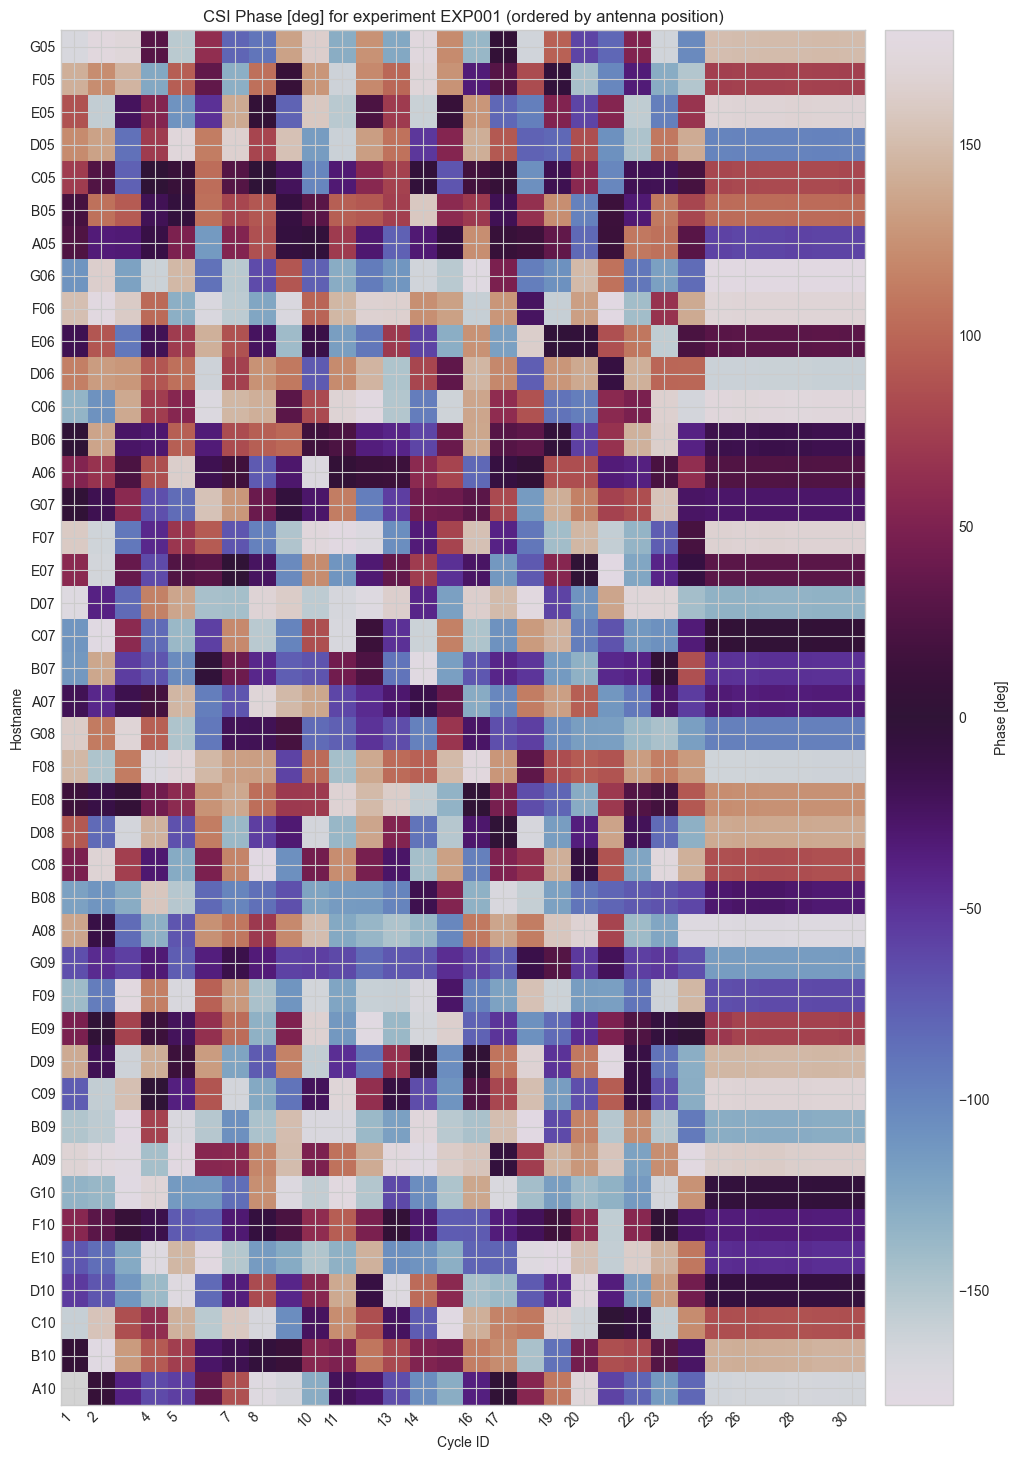

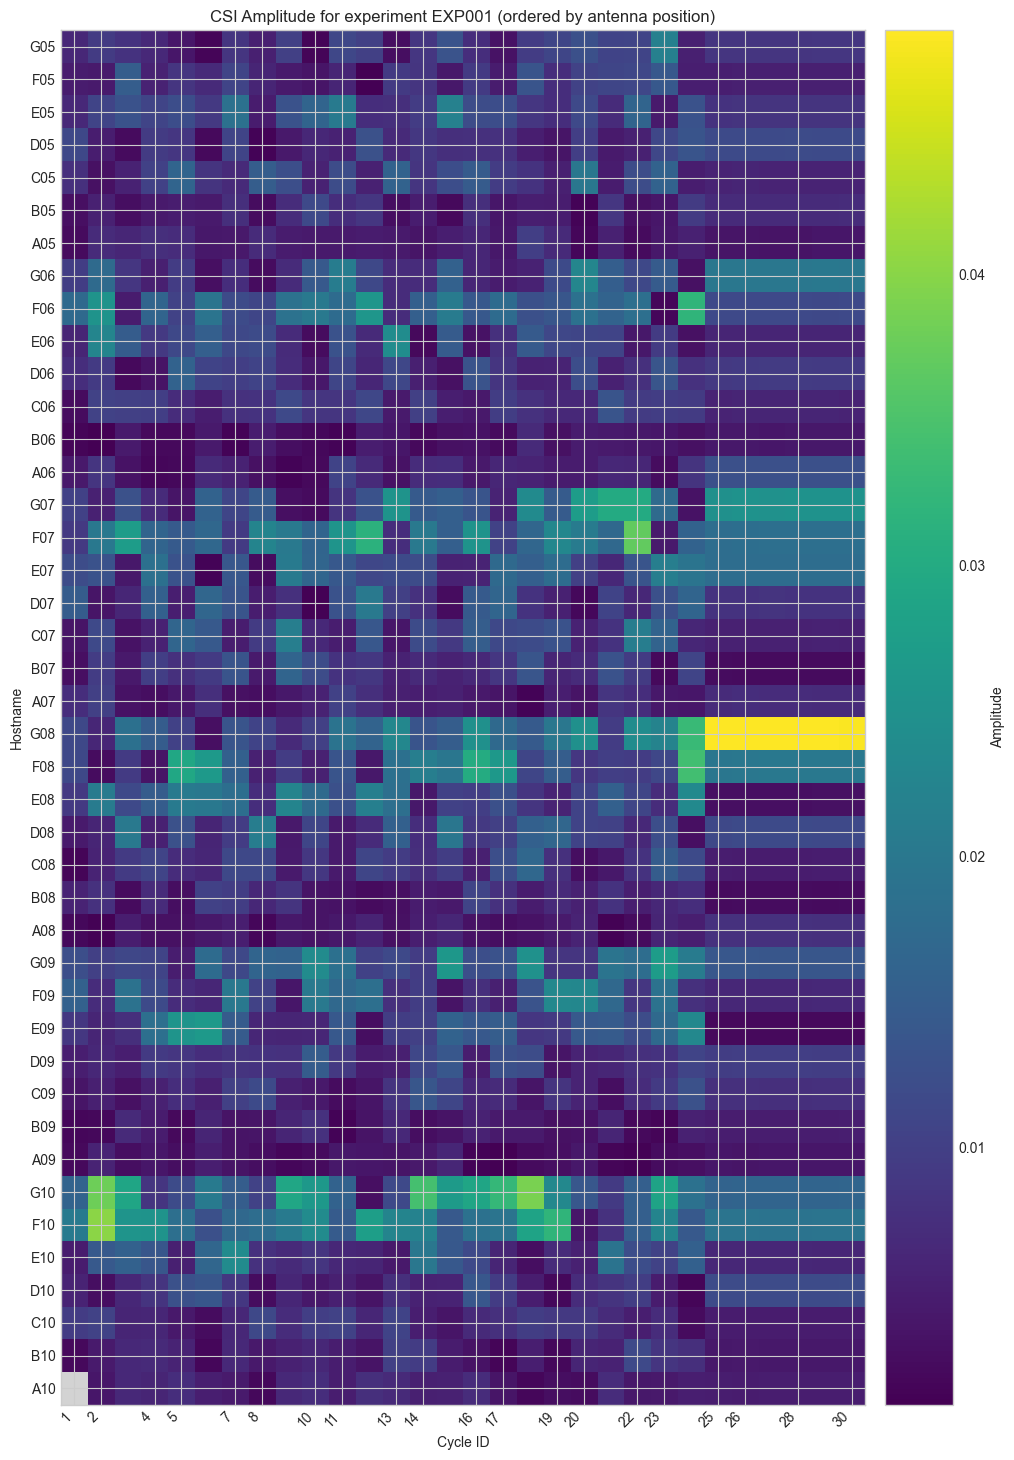

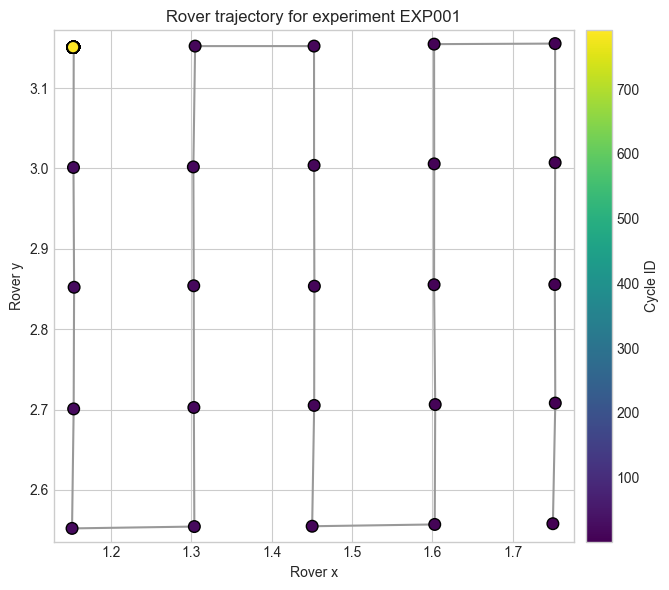

In [30]:
for experiment_id in experiment_ids:
    plot_phase_heatmap(ds, experiment_id)
    plt.show()
    plot_amplitude_heatmap(ds, experiment_id)
    plt.show()
    plot_trajectory(ds, experiment_id)
    plt.show()


Selected experiment: EXP001
Selected cycle: 1


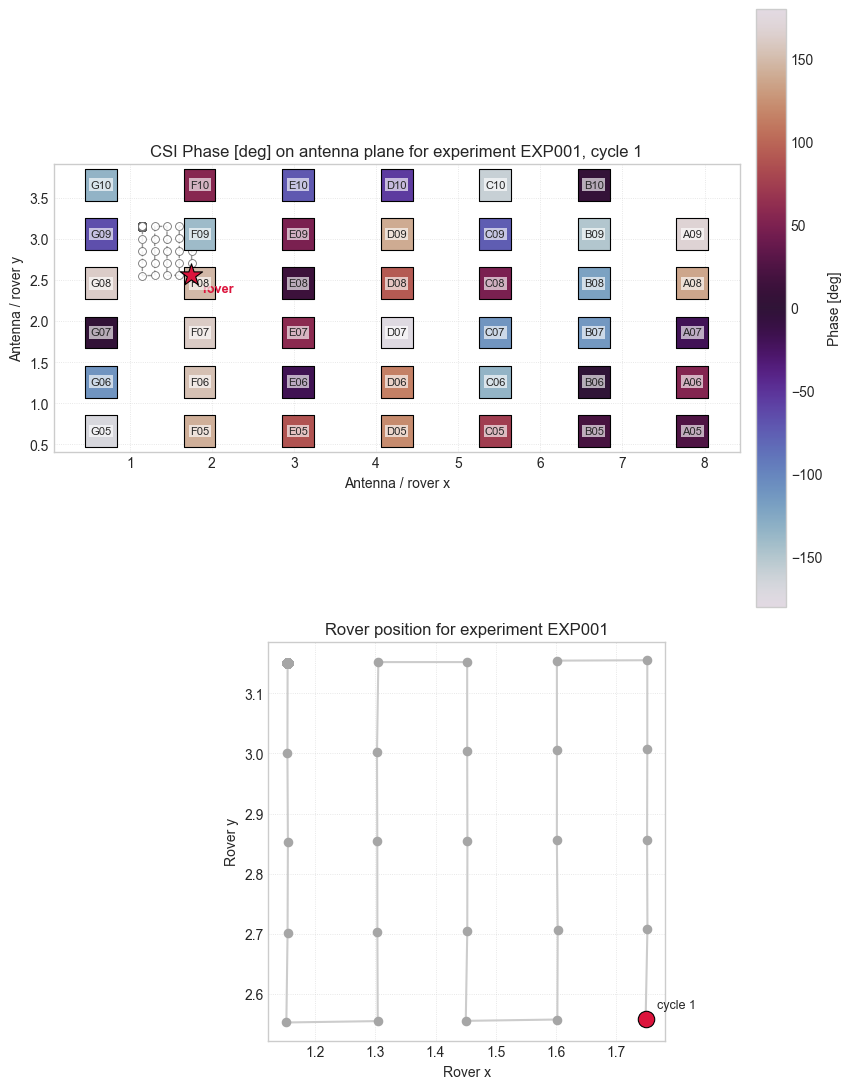

In [31]:
selected_experiment_id = experiment_ids[0]
selected_experiment = ds.sel(experiment_id=selected_experiment_id)
available_cycle_ids = selected_experiment['cycle_id'].values[
    (selected_experiment['csi_available'].values > 0).any(axis=1)
]
selected_cycle_id = int(available_cycle_ids[0])

print(f'Selected experiment: {selected_experiment_id}')
print(f'Selected cycle: {selected_cycle_id}')

plot_phase_rover_frame(ds, selected_experiment_id, selected_cycle_id)
plt.show()


In [32]:
movie_path = create_phase_rover_movie(
    ds,
    selected_experiment_id,
    fps=2,
    file_format='gif',
)
print(f'Saved movie: {movie_path}')


Saved movie: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\data\phase_rover_EXP001.gif


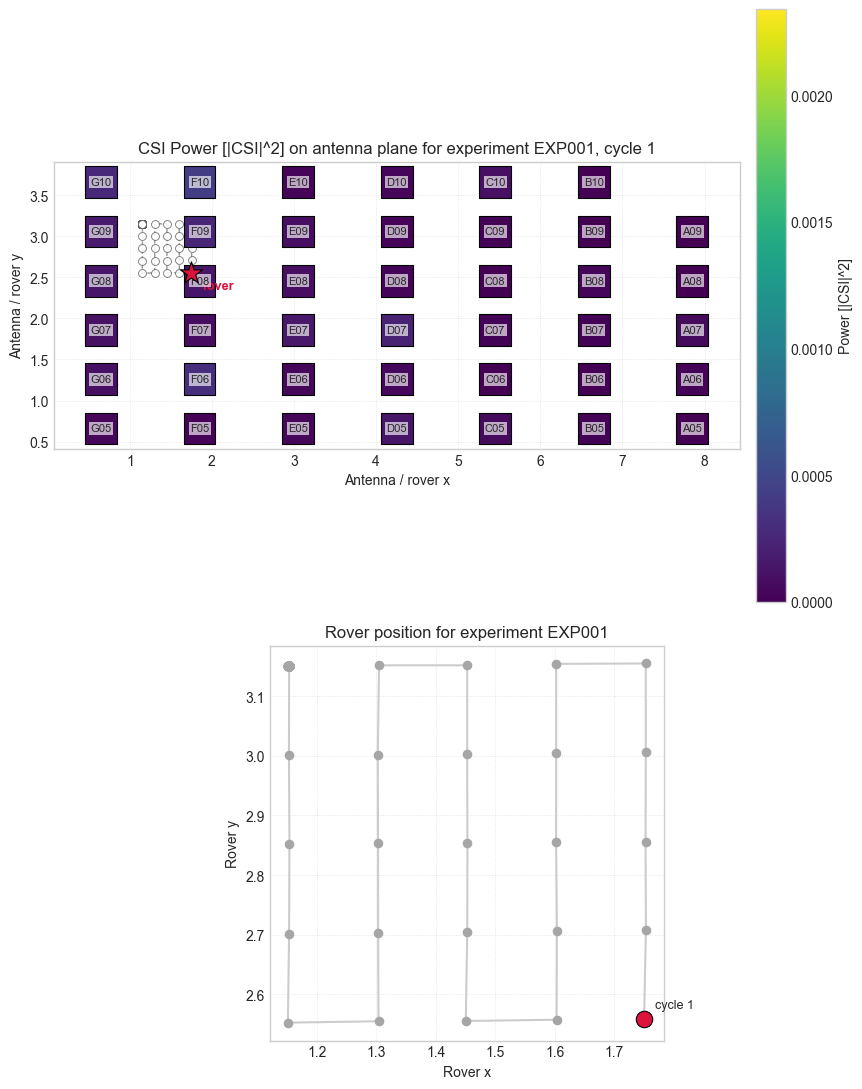

In [33]:
plot_power_rover_frame(ds, selected_experiment_id, selected_cycle_id)
plt.show()


In [34]:
power_movie_path = create_power_rover_movie(
    ds,
    selected_experiment_id,
    fps=2,
    file_format='gif',
)
print(f'Saved power movie: {power_movie_path}')


Saved power movie: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\data\power_rover_EXP001.gif
